<a href="https://colab.research.google.com/github/Debapriya1102iitp/Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis_by_Debapriya_Nag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis
### VOIS AICTE — Major Project
 by Debapriya Nag , Batch 1

**Project focus:** understand how agricultural performance changes across Kharif, Rabi and Zaid seasons, and investigate crop, resource, environmental, regional and economic patterns.

This notebook follows the official brief: explore and clean the dataset, compare seasonal performance, investigate relationships, identify unusual patterns, apply appropriate statistical and visualization techniques, interpret evidence, and develop recommendations.

## 1. Business / Analytical Questions

1. How does agricultural performance vary across seasons?
2. Which season has the strongest yield and profitability?
3. Which crops perform best in different seasons?
4. How do irrigation methods affect yield, water use and water efficiency?
5. What relationships exist between environmental/resource variables and yield or profit?
6. How do economic outcomes vary across regions?
7. Are there unusual observations or outliers that deserve investigation?
8. What evidence-based recommendations can support seasonal agricultural planning?

In [ ]:
# Imports and Colab-ready dataset loading
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = 'seasonal_agriculture_performance_dataset.xlsx'

if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        uploaded = files.upload()
        DATA_PATH = next(iter(uploaded.keys()))
    except ImportError:
        raise FileNotFoundError(
            "Place seasonal_agriculture_performance_dataset.xlsx in the working folder."
        )

df = pd.read_excel(DATA_PATH)
pd.set_option('display.max_columns', None)
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 2. Dataset Overview

The dataset contains farm-level observations covering geography, crop, season, environmental conditions, inputs, irrigation, production, market/economic outcomes, water use and disease/pest risk.

In [ ]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nData types:')
display(df.dtypes.to_frame('dtype'))

Shape: (4000, 28)

Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


,dtype
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


## 3. Data Quality Check & Cleaning

The original dataset contains **4,000 records and 28 columns**. The quality check identifies missing values in Rainfall, Soil Moisture and Yield. There are no exact duplicate rows. Numeric missing values are median-imputed for the analytical dataset so seasonal comparisons do not lose records; the imputed values should not be treated as observed measurements.

In [ ]:
quality = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Percent': (df.isna().mean()*100).round(2)
})
quality = quality[quality['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print('Exact duplicate rows:', df.duplicated().sum())
display(quality)

Exact duplicate rows: 0


,Missing_Count,Missing_Percent
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [ ]:
df_clean = df.drop_duplicates().copy()
num_cols = df_clean.select_dtypes(include=np.number).columns
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print('Rows after duplicate handling:', len(df_clean))
print('Remaining missing values:', int(df_clean.isna().sum().sum()))

Rows after duplicate handling: 4000
Remaining missing values: 0


## 4. Feature Engineering

The following derived indicators make the analysis more decision-oriented:
- **Profit Margin (%)** = Profit / Revenue × 100
- **Cost per Hectare**
- **Revenue per Hectare**
- **Profit per Hectare**

In [ ]:
df_clean['Profit_Margin_pct'] = np.where(df_clean['Revenue_INR'] != 0,
                                           df_clean['Profit_INR'] / df_clean['Revenue_INR'] * 100, np.nan)
df_clean['Cost_per_Hectare_INR'] = df_clean['Total_Cost_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Revenue_per_Hectare_INR'] = df_clean['Revenue_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Profit_per_Hectare_INR'] = df_clean['Profit_INR'] / df_clean['Farm_Area_Hectares']

display(df_clean[['Profit_Margin_pct','Cost_per_Hectare_INR','Revenue_per_Hectare_INR','Profit_per_Hectare_INR']].describe().round(2))

,Profit_Margin_pct,Cost_per_Hectare_INR,Revenue_per_Hectare_INR,Profit_per_Hectare_INR
count,4000.00,4000.00,4000.00,4000.00
mean,-45.49,66660.08,80215.11,13555.02
std,158.09,8845.64,58262.57,58939.07
min,-1461.85,35807.38,4439.47,-83127.37
25%,-60.19,60597.21,42325.16,-25353.73
50%,1.15,66614.05,67082.98,778.69
75%,32.89,72739.98,96800.41,31262.42
max,85.92,97185.35,422793.51,356585.58


## 5. Seasonal Performance — Core Analysis

In [ ]:
season = (df_clean.groupby('Season')
          .agg(Farms=('Farm_ID','count'),
               Yield_Tonnes_Ha=('Yield_Tonnes_Ha','mean'),
               Production_Tonnes=('Production_Tonnes','mean'),
               Revenue_INR=('Revenue_INR','mean'),
               Total_Cost_INR=('Total_Cost_INR','mean'),
               Profit_INR=('Profit_INR','mean'),
               Profit_Margin_pct=('Profit_Margin_pct','mean'),
               Water_Used_m3=('Water_Used_m3','mean'),
               Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean'),
               Disease_Pest_Risk=('Disease_Pest_Risk_pct','mean'),
               Rainfall_mm=('Rainfall_mm','mean'))
          .round(2))
display(season)

,Farms,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_pct,Water_Used_m3,Water_Efficiency,Disease_Pest_Risk,Rainfall_mm
Season,,,,,,,,,,,
Kharif,1779,5.63,46.31,710719.06,531804.41,178914.65,-38.64,6102.20,5.89,54.47,849.20
Rabi,1627,5.04,41.49,601526.05,513836.58,87689.47,-44.27,5846.99,5.19,40.48,437.62
Zaid,594,4.64,38.89,519171.90,543976.73,-24804.82,-69.35,6419.89,4.41,38.22,304.65


### 5.1 Average Yield by Season

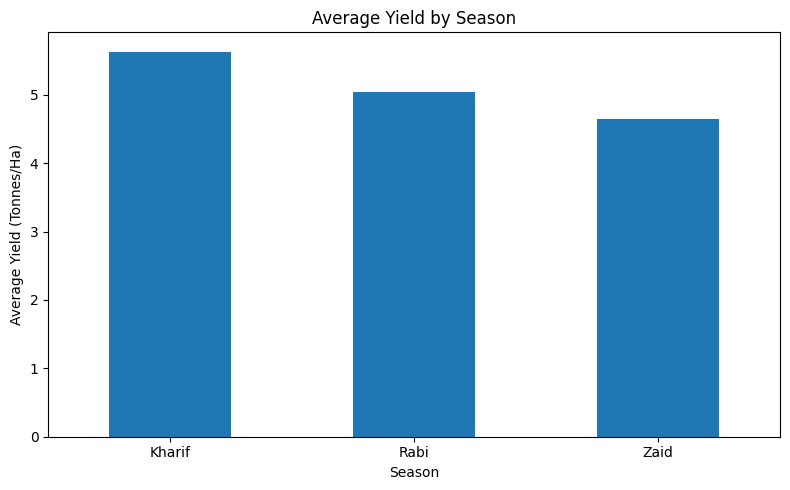

In [ ]:
plt.figure(figsize=(8,5))
season['Yield_Tonnes_Ha'].sort_values(ascending=False).plot(kind='bar')
plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.2 Average Profit by Season

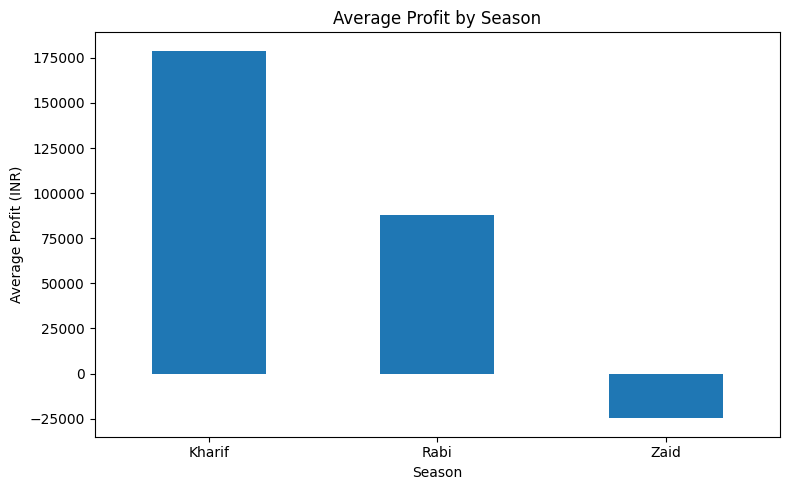

In [ ]:
plt.figure(figsize=(8,5))
season['Profit_INR'].plot(kind='bar')
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.3 Seasonal Distribution of Yield — Boxplot

/tmp/ipykernel_1643/3537838947.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=['Kharif','Rabi','Zaid'], showfliers=True)


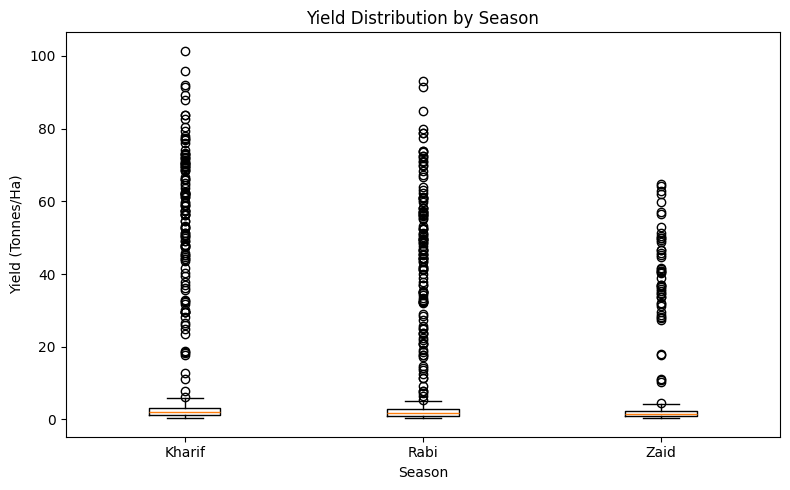

In [ ]:
plt.figure(figsize=(8,5))
box_data = [df_clean.loc[df_clean['Season']==s, 'Yield_Tonnes_Ha'] for s in ['Kharif','Rabi','Zaid']]
plt.boxplot(box_data, labels=['Kharif','Rabi','Zaid'], showfliers=True)
plt.title('Yield Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

### 5.4 Yield Distribution — Histogram

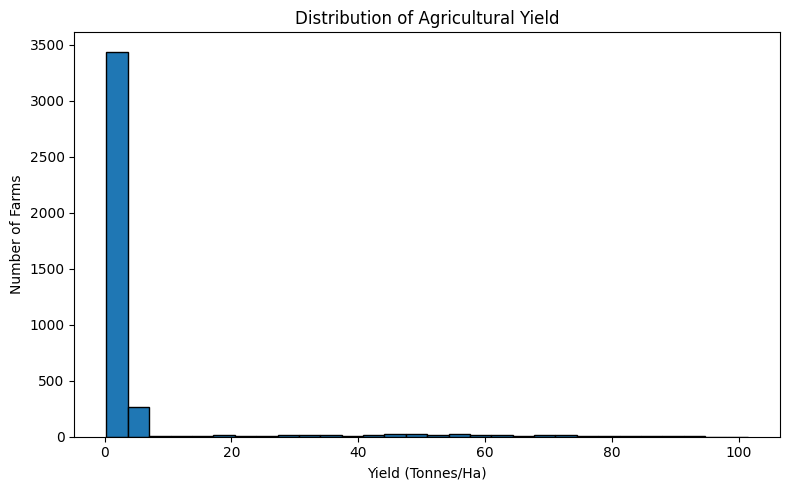

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df_clean['Yield_Tonnes_Ha'], bins=30, edgecolor='black')
plt.title('Distribution of Agricultural Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Number of Farms')
plt.tight_layout()
plt.show()

### Seasonal interpretation

In this dataset, **Kharif has the highest average yield and average profit**, while **Zaid has the lowest average yield and a negative average profit**. Kharif also has the highest average rainfall and disease/pest risk. These are descriptive patterns and should not be interpreted as causal effects.

## 6. Crop Performance

In [ ]:
crop = (df_clean.groupby('Crop')
        .agg(Farms=('Farm_ID','count'),
             Yield=('Yield_Tonnes_Ha','mean'),
             Profit=('Profit_INR','mean'),
             Revenue=('Revenue_INR','mean'),
             Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean'),
             Risk=('Disease_Pest_Risk_pct','mean'))
        .sort_values('Profit', ascending=False).round(2))
display(crop)

,Farms,Yield,Profit,Revenue,Water_Efficiency,Risk
Crop,,,,,,
Sugarcane,305,46.64,817187.99,1371980.11,30.48,45.40
Chilli,412,1.54,750878.34,1276777.23,2.95,46.06
Cotton,508,1.23,124546.92,639423.08,1.94,45.97
Groundnut,424,1.32,44858.12,542935.50,3.15,46.29
Pulses,496,0.92,-4238.05,528465.87,2.90,46.57
Maize,551,2.71,-83978.33,457067.99,5.60,45.54
Rice,690,2.43,-102213.50,423615.26,1.95,46.50
Wheat,614,2.11,-123398.34,400104.89,4.63,47.85


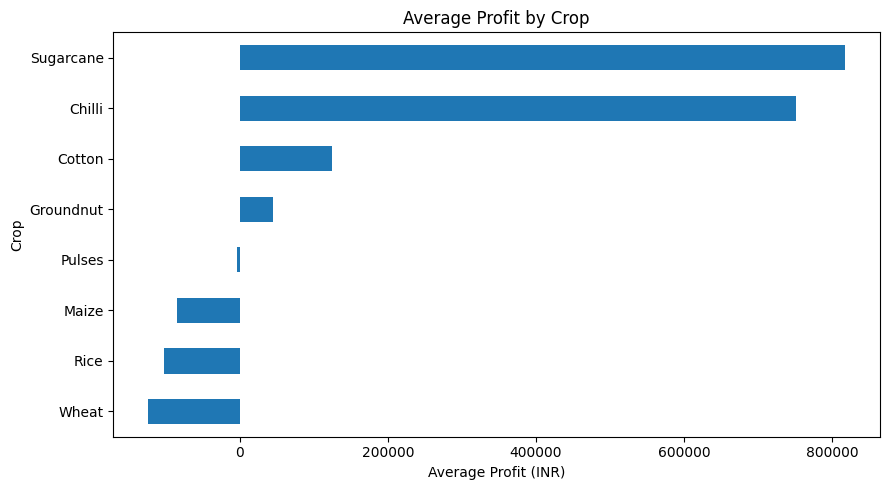

In [ ]:
plt.figure(figsize=(9,5))
crop['Profit'].sort_values().plot(kind='barh')
plt.title('Average Profit by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

### Crop × Season Yield Heatmap

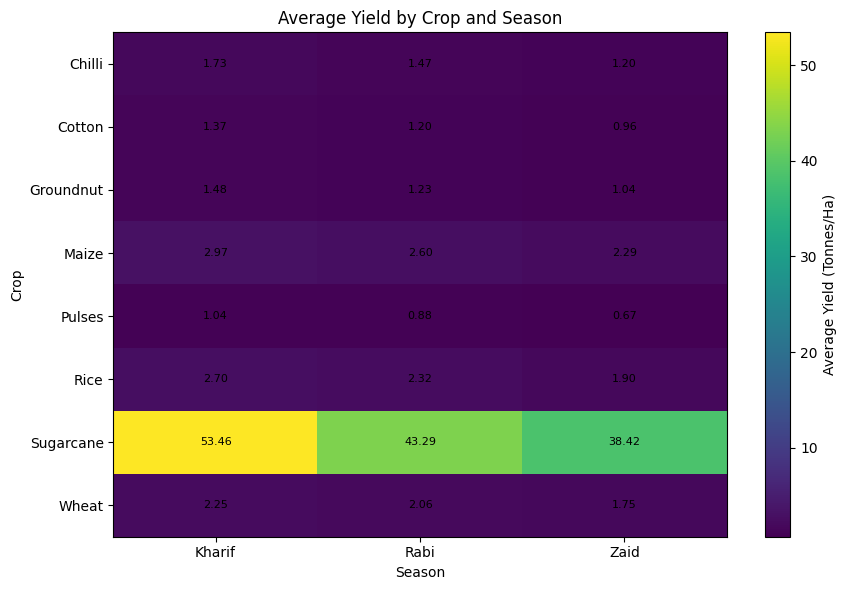

In [ ]:
pivot = df_clean.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean')
plt.figure(figsize=(9,6))
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Average Yield (Tonnes/Ha)')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i,j]
        if pd.notna(val):
            plt.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8)
plt.title('Average Yield by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

## 7. Resource & Irrigation Analysis

In [ ]:
irrig = (df_clean.groupby('Irrigation_Method')
         .agg(Farms=('Farm_ID','count'),
              Yield=('Yield_Tonnes_Ha','mean'),
              Profit=('Profit_INR','mean'),
              Water_Used=('Water_Used_m3','mean'),
              Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean'))
         .round(2))
display(irrig)

,Farms,Yield,Profit,Water_Used,Water_Efficiency
Irrigation_Method,,,,,
Drip,915,6.58,219626.00,5918.75,6.27
Flood,1310,4.86,73354.02,8026.47,3.44
Rainfed,1041,4.60,79050.37,3549.55,7.56
Sprinkler,734,5.16,91121.08,6208.26,4.67


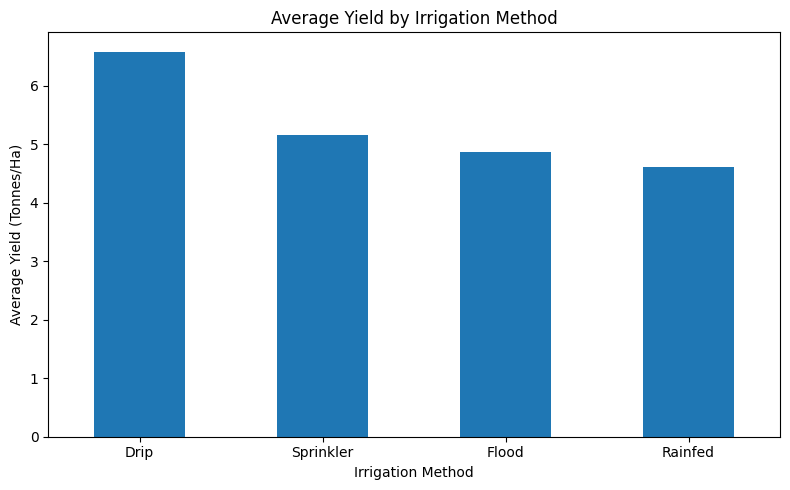

In [ ]:
plt.figure(figsize=(8,5))
irrig['Yield'].sort_values(ascending=False).plot(kind='bar')
plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

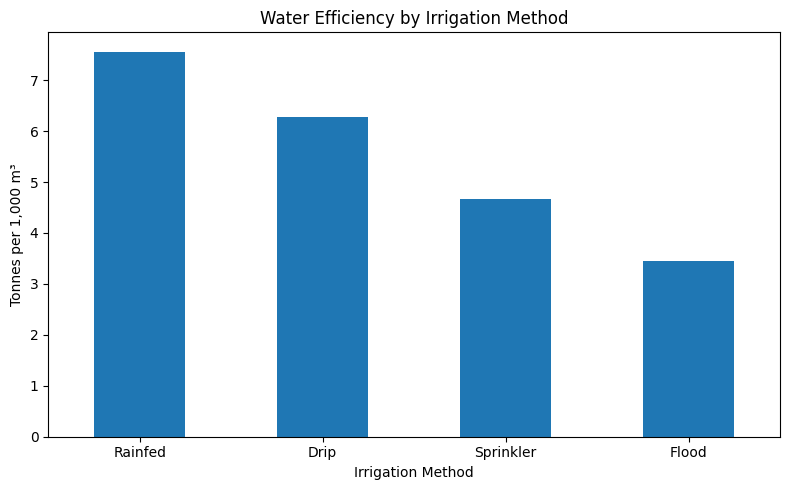

In [ ]:
plt.figure(figsize=(8,5))
irrig['Water_Efficiency'].sort_values(ascending=False).plot(kind='bar')
plt.title('Water Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Tonnes per 1,000 m³')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** Drip has the highest average yield among the four irrigation methods in this dataset. Rainfed has the highest average water-efficiency metric and the lowest average water use. These comparisons are observational and may be affected by crop, soil, regional and seasonal differences.

## 8. Environmental Relationships

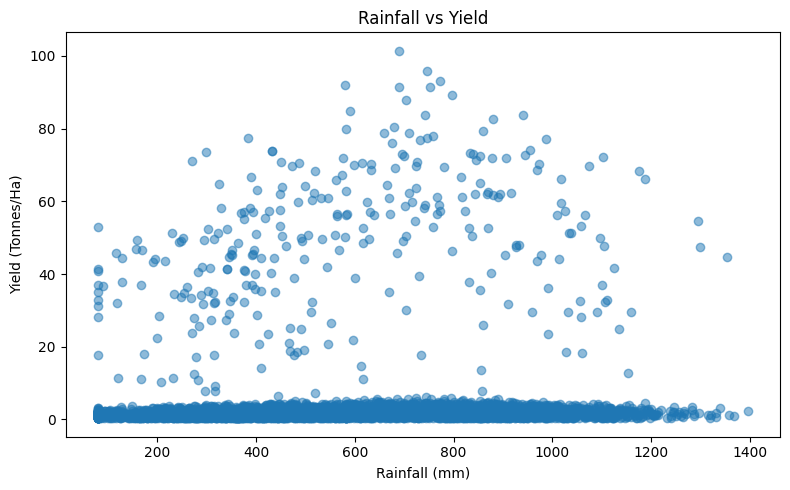

In [ ]:
# Scatter: rainfall vs yield
plt.figure(figsize=(8,5))
plt.scatter(df_clean['Rainfall_mm'], df_clean['Yield_Tonnes_Ha'], alpha=0.5)
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.title('Rainfall vs Yield')
plt.tight_layout()
plt.show()

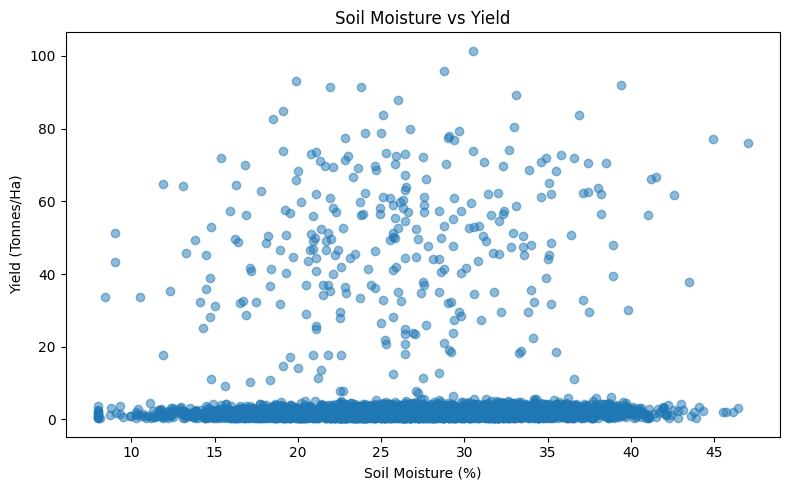

In [ ]:
# Scatter: soil moisture vs yield
plt.figure(figsize=(8,5))
plt.scatter(df_clean['Soil_Moisture_pct'], df_clean['Yield_Tonnes_Ha'], alpha=0.5)
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.title('Soil Moisture vs Yield')
plt.tight_layout()
plt.show()

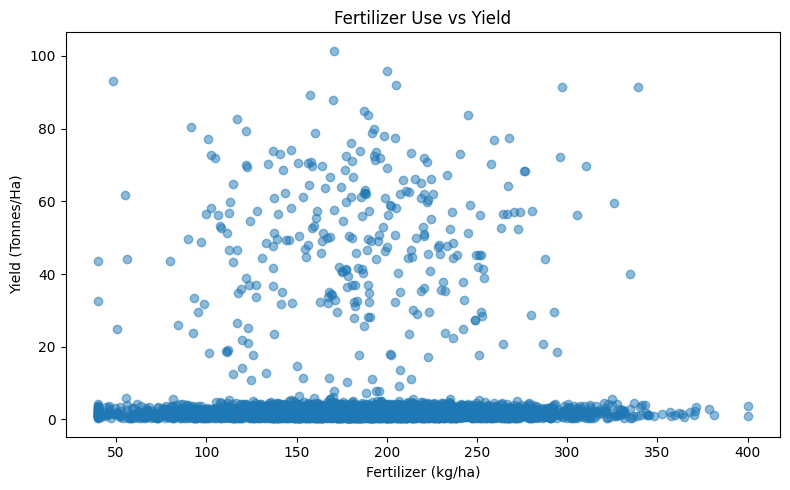

In [ ]:
# Scatter: fertilizer vs yield
plt.figure(figsize=(8,5))
plt.scatter(df_clean['Fertilizer_kg_ha'], df_clean['Yield_Tonnes_Ha'], alpha=0.5)
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.title('Fertilizer Use vs Yield')
plt.tight_layout()
plt.show()

## 9. Correlation Analysis

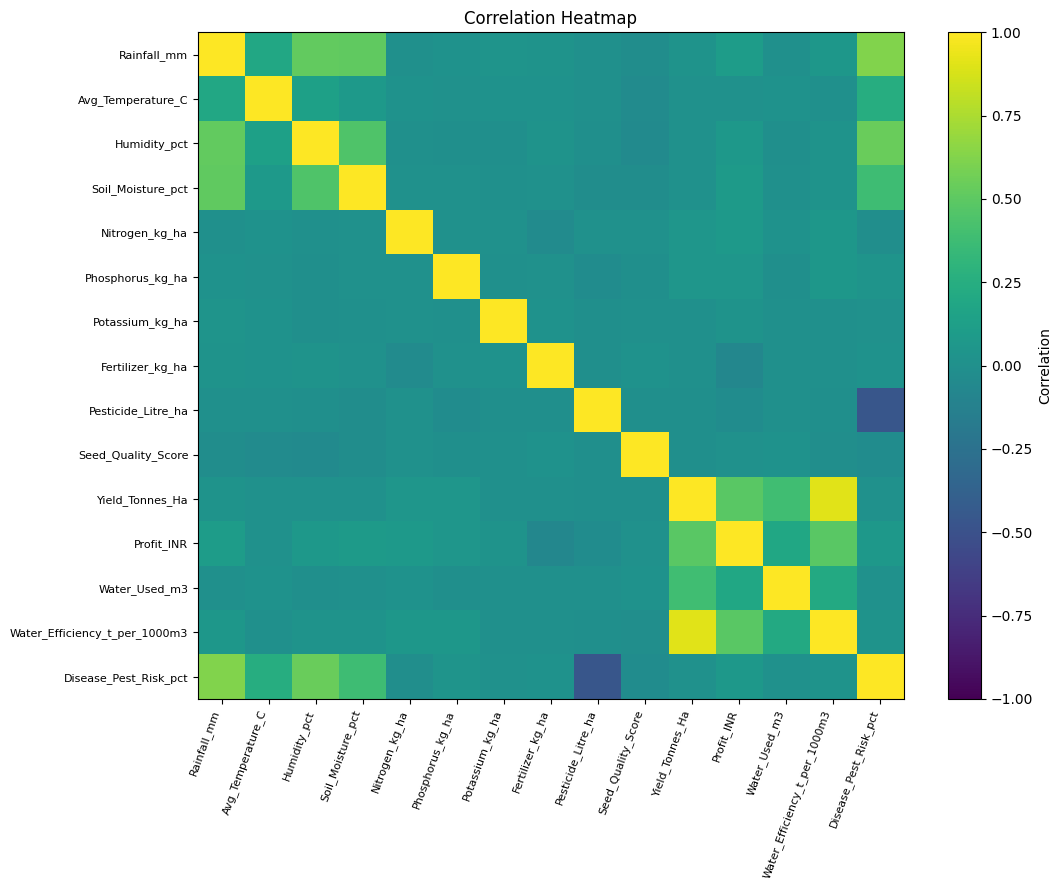

Top correlations with Yield:


,Correlation
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Profit_INR,0.488466
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Disease_Pest_Risk_pct,0.014292


Top correlations with Profit:


,Correlation
Profit_INR,1.000000
Water_Efficiency_t_per_1000m3,0.489487
Yield_Tonnes_Ha,0.488466
Water_Used_m3,0.190278
Rainfall_mm,0.107648
Soil_Moisture_pct,0.091281
Nitrogen_kg_ha,0.085016
Disease_Pest_Risk_pct,0.067583


In [ ]:
corr_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct',
             'Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha','Fertilizer_kg_ha',
             'Pesticide_Litre_ha','Seed_Quality_Score','Yield_Tonnes_Ha','Profit_INR',
             'Water_Used_m3','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']
corr = df_clean[corr_cols].corr()
plt.figure(figsize=(11,9))
plt.imshow(corr, aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=70, ha='right', fontsize=8)
plt.yticks(range(len(corr.index)), corr.index, fontsize=8)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print('Top correlations with Yield:')
display(corr['Yield_Tonnes_Ha'].sort_values(ascending=False).head(8).to_frame('Correlation'))
print('Top correlations with Profit:')
display(corr['Profit_INR'].sort_values(ascending=False).head(8).to_frame('Correlation'))

### Interpretation

Yield has a very strong positive association with the dataset's **water-efficiency measure**, while profit is positively associated with yield and water efficiency. Environmental variables such as rainfall show much weaker linear correlations with yield in the full sample. Correlation measures association, not causation.

## 10. Regional Comparison

In [ ]:
state = (df_clean.groupby('State')
        .agg(Farms=('Farm_ID','count'), Yield=('Yield_Tonnes_Ha','mean'), Profit=('Profit_INR','mean'),
             Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean'), Risk=('Disease_Pest_Risk_pct','mean'))
        .sort_values('Profit', ascending=False).round(2))
display(state)

,Farms,Yield,Profit,Water_Efficiency,Risk
State,,,,,
Punjab,484,6.12,136025.64,5.62,46.00
Maharashtra,512,5.02,135428.86,5.28,46.44
Karnataka,489,5.69,119422.34,5.56,46.06
Tamil Nadu,485,4.88,117744.75,5.31,46.28
Gujarat,488,5.66,117568.24,5.58,45.95
Telangana,516,5.04,108829.62,5.46,46.36
Madhya Pradesh,497,4.99,86840.76,5.27,47.08
Andhra Pradesh,529,4.63,73453.53,5.03,46.72


In [ ]:
plt.figure(figsize=(9,5))
state['Profit'].sort_values().plot(kind='barh')
plt.title('Average Profit by State')
plt.xlabel('Average Profit (INR)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## 11. Economic Distribution — Histogram

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df_clean['Profit_INR'], bins=35, edgecolor='black')
plt.title('Distribution of Farm Profit')
plt.xlabel('Profit (INR)')
plt.ylabel('Number of Farms')
plt.tight_layout()
plt.show()

## 12. Unusual Patterns & Outlier Analysis

In [ ]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    return int(((series < low) | (series > high)).sum()), low, high

for col in ['Yield_Tonnes_Ha','Profit_INR','Water_Used_m3','Disease_Pest_Risk_pct']:
    count, low, high = iqr_outlier_count(df_clean[col])
    print(f'{col}: {count} IQR outliers | bounds = ({low:.2f}, {high:.2f})')

In [ ]:
# Top and bottom observations by yield and profit
print('Highest-yield observations:')
display(df_clean.nlargest(5, 'Yield_Tonnes_Ha')[['Farm_ID','State','Crop','Season','Yield_Tonnes_Ha','Profit_INR']])
print('\nLowest-profit observations:')
display(df_clean.nsmallest(5, 'Profit_INR')[['Farm_ID','State','Crop','Season','Yield_Tonnes_Ha','Revenue_INR','Total_Cost_INR','Profit_INR']])

Highest-yield observations:


,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha,Profit_INR
1715,SF11716,Gujarat,Sugarcane,Kharif,101.44,1608291
3423,SF13424,Andhra Pradesh,Sugarcane,Kharif,95.79,3330582
3525,SF13526,Andhra Pradesh,Sugarcane,Rabi,93.13,1471529
1464,SF11465,Gujarat,Sugarcane,Kharif,91.98,2216708
3523,SF13524,Karnataka,Sugarcane,Kharif,91.46,234320



Lowest-profit observations:


,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR
780,SF10781,Andhra Pradesh,Groundnut,Rabi,0.30,280139,1299362,-1019223
2210,SF12211,Andhra Pradesh,Wheat,Rabi,0.30,102497,1097692,-995195
3625,SF13626,Punjab,Maize,Rabi,0.97,226503,1207553,-981050
2182,SF12183,Andhra Pradesh,Rice,Kharif,1.01,320865,1297725,-976860
104,SF10105,Gujarat,Wheat,Zaid,0.30,98792,1063989,-965197


## 13. Statistical Test — Do Seasons Differ in Yield?

Because yield distributions contain outliers and need not be normally distributed, the **Kruskal–Wallis test** is used as a robust comparison of the three seasonal groups.

- **H₀:** the seasonal yield distributions are the same.
- **H₁:** at least one season differs.
- Significance level: α = 0.05.

In [ ]:
from scipy.stats import kruskal

groups = [df_clean.loc[df_clean['Season']==s, 'Yield_Tonnes_Ha'] for s in ['Kharif','Rabi','Zaid']]
stat, p = kruskal(*groups)
print(f'Kruskal-Wallis H = {stat:.3f}')
print(f'p-value = {p:.6g}')
if p < 0.05:
    print('Decision: reject H0 — there is a statistically significant difference among seasonal yield distributions.')
else:
    print('Decision: fail to reject H0 — no statistically significant seasonal difference detected.')

Kruskal-Wallis H = 68.713
p-value = 1.19991e-15
Decision: reject H0 — there is a statistically significant difference among seasonal yield distributions.


## 14. Key Findings

The following findings are directly supported by the descriptive and statistical analysis above.

In [30]:
best_yield_season = season['Yield_Tonnes_Ha'].idxmax()
best_profit_season = season['Profit_INR'].idxmax()
worst_profit_season = season['Profit_INR'].idxmin()
best_crop_profit = crop['Profit'].idxmax()
best_irrig_yield = irrig['Yield'].idxmax()
best_state_profit = state['Profit'].idxmax()

print(f'1. Highest average yield season: {best_yield_season} ({season.loc[best_yield_season,"Yield_Tonnes_Ha"]:.2f} tonnes/ha).')
print(f'2. Highest average profit season: {best_profit_season} (INR {season.loc[best_profit_season,"Profit_INR"]:,.0f}).')
print(f'3. Lowest average profit season: {worst_profit_season} (INR {season.loc[worst_profit_season,"Profit_INR"]:,.0f}).')
print(f'4. Highest-profit crop: {best_crop_profit} (INR {crop.loc[best_crop_profit,"Profit"]:,.0f} average).')
print(f'5. Highest-yield irrigation method: {best_irrig_yield} ({irrig.loc[best_irrig_yield,"Yield"]:.2f} tonnes/ha average).')
print(f'6. Highest-average-profit state: {best_state_profit} (INR {state.loc[best_state_profit,"Profit"]:,.0f}).')
print(f'7. Yield vs water-efficiency correlation: {corr.loc["Yield_Tonnes_Ha","Water_Efficiency_t_per_1000m3"]:.2f}.')

1. Highest average yield season: Kharif (5.63 tonnes/ha).
2. Highest average profit season: Kharif (INR 178,915).
3. Lowest average profit season: Zaid (INR -24,805).
4. Highest-profit crop: Sugarcane (INR 817,188 average).
5. Highest-yield irrigation method: Drip (6.58 tonnes/ha average).
6. Highest-average-profit state: Punjab (INR 136,026).
7. Yield vs water-efficiency correlation: 0.91.


## 15. Data-Driven Recommendations

1. **Use season-specific planning:** Kharif, Rabi and Zaid show materially different yield and profit profiles, so a single benchmark is not appropriate.
2. **Investigate Zaid economics:** the negative average profit warrants review of production costs, market prices, water requirements and crop mix before expansion.
3. **Evaluate high-performing crops carefully:** Sugarcane and Chilli show high average profitability in this sample, but their resource and risk requirements should be assessed before recommending wider adoption.
4. **Improve resource efficiency:** compare irrigation methods in the context of crop and regional conditions, rather than treating method-level averages as causal effects.
5. **Use regional comparisons for targeting:** high- and low-performing states can be prioritized for deeper investigation of local practices, costs and environmental conditions.
6. **Extend the dataset over time:** multi-year weather and market-price data would improve seasonal forecasting and planning.

## 16. Conclusion

The analysis shows clear descriptive differences in agricultural performance across seasons. **Kharif records the strongest average yield and profit, while Zaid presents the largest profitability challenge.** Crop choice, irrigation method and regional context also show meaningful variation. The correlation and statistical analyses add evidence about relationships and seasonal differences, while the outlier analysis highlights observations requiring further investigation. Overall, the project provides an evidence-based foundation for seasonal agricultural planning, while recognizing that observational data cannot by itself establish causation.